In [16]:
import numpy as np
from scipy import optimize

In [17]:
params = (2, 3, 7, 8, 9, 10, 44, -1, 2, 26, 1, -2, 0.5)

In [18]:
def f1(z, *params):
    x, y = z
    a, b, c, d, e, f, g, h, i, j, k, l, scale = params
    return (a * x**2 + b * x * y + c * y**2 + d*x + e*y + f)

In [19]:
def f2(z, *params):
    x, y = z
    a, b, c, d, e, f, g, h, i, j, k, l, scale = params
    return (-g*np.exp(-((x-h)**2 + (y-i)**2) / scale))

In [20]:
def f3(z, *params):
    x, y = z
    a, b, c, d, e, f, g, h, i, j, k, l, scale = params
    return (-j*np.exp(-((x-k)**2 + (y-l)**2) / scale))

In [21]:
def f(z, *params):
    return f1(z, *params) + f2(z, *params) + f3(z, *params)

In [23]:
f1((1,1), *params)

39

In [24]:
f2((1,1), *params)

-0.0019975969095493338

In [25]:
f3((1,1), *params)

-3.959794733625284e-07

In [26]:
f((1,1), *params)

38.998002007110976

In [27]:
rranges = (slice(-4, 4, 0.25), slice(-4, 4, 0.25))


In [28]:
resbrute = optimize.brute(f, rranges, args=params, full_output=True,
                          finish=optimize.fmin)

In [30]:
slice(-4, 4, 0.25)

slice(-4, 4, 0.25)

In [32]:
f(resbrute[0], *params)

-3.4085818767996527

In [31]:
f(resbrute[0], *params)

array([-1.05665192,  1.80834843])

In [36]:
import matplotlib.pyplot as plt

In [231]:
toy = np.random.normal(size=1000)


In [232]:
counts, edges = np.histogram(toy, bins=100)

In [233]:
def gaussian(params):
    a,x0,sig=params
    x = np.arange(100)
    return a*np.exp(-(x-x0)**2 / (2*sig**2))

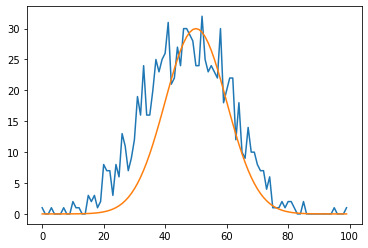

In [238]:
xx = np.arange(100)

plt.plot(xx, counts)
plt.plot(xx, gaussian([30, 50, 10]))

In [241]:
def chi_func(params):
    
    chisq = np.sum((counts - gaussian(params))**2)
    
    return chisq

In [242]:
xi = np.array([30,50,10])

In [243]:
result = optimize.minimize(chi_func, xi)

In [244]:
result

      fun: 583.6570144167757
 hess_inv: array([[ 2.70767618e-02,  8.75105641e-06, -1.01231853e-02],
       [ 8.75105641e-06,  1.23952883e-02,  1.21536182e-03],
       [-1.01231853e-02,  1.21536182e-03,  9.46036061e-03]])
      jac: array([0.00000000e+00, 7.62939453e-06, 7.62939453e-06])
  message: 'Optimization terminated successfully.'
     nfev: 68
      nit: 12
     njev: 17
   status: 0
  success: True
        x: array([28.3349509 , 47.48711629, 14.23448059])

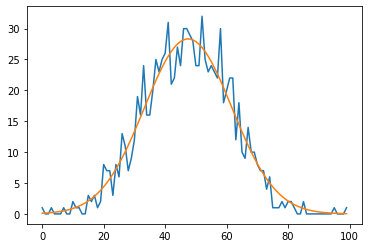

In [245]:
xx = np.arange(100)

plt.plot(xx, counts)
# plt.plot(xx, gaussian([350, 50, 30]))
plt.plot(xx, gaussian(result.x))

In [150]:
def makeGaussian2(x_center=50, y_center=50, theta=0, sigma_x = 10, sigma_y=10, x_size=100, y_size=100):
    # x_center and y_center will be the center of the gaussian, theta will be the rotation angle
    # sigma_x and sigma_y will be the stdevs in the x and y axis before rotation
    # x_size and y_size give the size of the frame 

    theta = 2*np.pi*theta/360
    x = np.arange(0,x_size, 1, float)
    y = np.arange(0,y_size, 1, float)
    y = y[:,np.newaxis]
    sx = sigma_x
    sy = sigma_y
    x0 = x_center
    y0 = y_center

    # rotation
    a=np.cos(theta)*x -np.sin(theta)*y
    b=np.sin(theta)*x +np.cos(theta)*y
    a0=np.cos(theta)*x0 -np.sin(theta)*y0
    b0=np.sin(theta)*x0 +np.cos(theta)*y0

    return np.exp(-(((a-a0)**2)/(2*(sx**2)) + ((b-b0)**2) /(2*(sy**2))))

In [175]:
g2d = makeGaussian2()

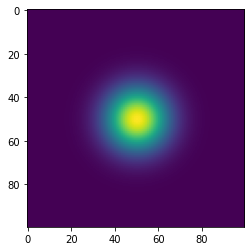

In [177]:
plt.imshow(g2d)

In [278]:
def gaussian2d(params):
    x0,y0,sig_a,sig_b=params
    a,b = np.arange(1000), np.arange(1000)
    b = b[:,np.newaxis]
    return np.exp(-(((a-x0)**2)/(2*(sig_a**2)) + ((b-y0)**2) /(2*(sig_b**2))))

In [159]:
gg

In [479]:
xg = np.random.normal(size=1000)
yg = np.random.normal(size=1000)

In [480]:
gg = xg + yg[:,np.newaxis]

In [481]:
np.mean(gg, axis=1).shape

(1000,)

In [482]:
np.mean(test2d, axis=1).shape

(1000,)

In [483]:
params=[125,689,42,25]

In [484]:
test2d = gaussian2d(params=params)

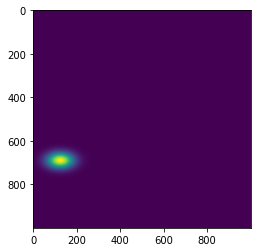

In [485]:
plt.imshow(test2d)

In [486]:
counts, edges=np.histogram(np.mean(gg, axis=1), bins=1000)

In [504]:
def chi_func2(params):
    
    chisq = np.sum((test2d - gaussian2d(params))**2)
    print(chisq)
    print(params)
    print('\n')
    return chisq

In [505]:
xi2 = np.array([10,700,15,1])
bnds = ((0,150),(600,750),(0,100),(0,100))

In [506]:
result2 = optimize.minimize(chi_func2, xi2, 
                            method='Powell', bounds=bnds, tol=1e-6)

3332.656365748249
[ 10. 700.  15.   1.]


3294.891935723202
[ 57.29490169 700.          15.           1.        ]


3221.8681672365674
[ 92.70509831 700.          15.           1.        ]


3189.0571674435278
[114.58980338 700.          15.           1.        ]


3185.1217873589694
[128.11529494 700.          15.           1.        ]


3184.744754885883
[125.6159388 700.         15.          1.       ]


3184.729409376811
[124.98324091 700.          15.           1.        ]


3184.7293980147892
[124.99956436 700.          15.           1.        ]


3184.729398007107
[125.0000004 700.         15.          1.       ]


3184.729398007107
[124.99999836 700.          15.           1.        ]


3184.7293980071076
[124.99999632 700.          15.           1.        ]


3266.286738748381
[124.99999836 657.29490169  15.           1.        ]


3170.3174619889646
[124.99999836 692.70509831  15.           1.        ]


3240.620740765076
[124.99999836 714.58980338  15.           1.        ]


In [497]:
result2

   direc: array([[ 7.57793806e-03,  2.47901104e-10, -1.20390024e-01,
         2.38776600e-02],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00],
       [-6.73311092e-08, -1.62576094e-15, -3.14650502e-09,
         6.59347228e-10]])
     fun: 4.842286795308091e-16
 message: 'Optimization terminated successfully.'
    nfev: 340
     nit: 6
  status: 0
 success: True
       x: array([125.        , 688.99999999,  41.99999999,  25.        ])

In [498]:
vals = gaussian2d(result2.x)

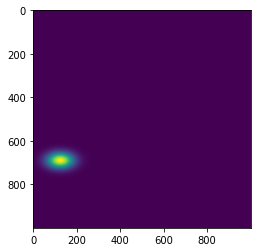

In [499]:
plt.imshow(vals)